# Análise dos hábitos de compra da Instacart

## Objetivo

Este projeto realiza a limpeza, o pré-processamento e a análise exploratória de dados de pedidos da Instacart.

A análise busca responder perguntas sobre:

- horários e dias com maior volume de pedidos;
- intervalo entre compras;
- frequência de pedidos por cliente;
- produtos mais comprados e recomprados;
- quantidade de itens por pedido;
- comportamento de recompra por produto e por cliente;
- produtos adicionados primeiro ao carrinho.

O projeto utiliza `pandas`, `NumPy` e `Matplotlib`.

## 1. Preparação do ambiente e carregamento dos dados

O código abaixo funciona em dois contextos:

- localmente, no VS Code, com os arquivos dentro da pasta `data`;
- na plataforma de estudos, com os arquivos dentro de `/datasets`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

LOCAL_DATA_DIR = Path('data')
PLATFORM_DATA_DIR = Path('/datasets')

if LOCAL_DATA_DIR.exists():
    DATA_DIR = LOCAL_DATA_DIR
else:
    DATA_DIR = PLATFORM_DATA_DIR

FIGURES_DIR = Path('reports/figures')
TABLES_DIR = Path('reports/tables')

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

def resolve_data_file(filename):
    regular_file = DATA_DIR / filename
    zipped_file = DATA_DIR / f'{filename}.zip'

    if regular_file.exists():
        return regular_file
    if zipped_file.exists():
        return zipped_file

    raise FileNotFoundError(
        f'Arquivo {filename} não encontrado em {DATA_DIR.resolve()}.'
    )

print(f'Diretório de dados utilizado: {DATA_DIR}')

Diretório de dados utilizado: data


In [2]:
orders = pd.read_csv(
    resolve_data_file('instacart_orders.csv'),
    sep=';'
)

products = pd.read_csv(
    resolve_data_file('products.csv'),
    sep=';'
)

order_products = pd.read_csv(
    resolve_data_file('order_products.csv'),
    sep=';'
)

aisles = pd.read_csv(
    resolve_data_file('aisles.csv'),
    sep=';'
)

departments = pd.read_csv(
    resolve_data_file('departments.csv'),
    sep=';'
)

dataframes = {
    'orders': orders,
    'products': products,
    'order_products': order_products,
    'aisles': aisles,
    'departments': departments
}

In [3]:
for name, dataframe in dataframes.items():
    print(f'\n{name.upper()}')
    print('-' * 60)
    display(dataframe.head())
    dataframe.info(show_counts=True)


ORDERS
------------------------------------------------------------


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.000
1,1690866,163593,5,5,12,9.000
2,1454967,39980,4,5,19,2.000
3,1768857,82516,56,0,20,10.000
4,3007858,196724,2,4,12,17.000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB

PRODUCTS
------------------------------------------------------------


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB

ORDER_PRODUCTS
------------------------------------------------------------


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB

AISLES
------------------------------------------------------------


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB

DEPARTMENTS
------------------------------------------------------------


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


### Observação inicial

Os arquivos utilizam ponto e vírgula como separador, por isso foi necessário informar `sep=';'` em `pd.read_csv()`.

A tabela `order_products` é a maior do conjunto e representa os itens individuais incluídos em cada pedido.

## 2. Pré-processamento dos dados

In [4]:
summary = []

for name, dataframe in dataframes.items():
    summary.append({
        'dataframe': name,
        'rows': dataframe.shape[0],
        'columns': dataframe.shape[1],
        'duplicated_rows': dataframe.duplicated().sum(),
        'missing_values': int(dataframe.isna().sum().sum())
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

,dataframe,rows,columns,duplicated_rows,missing_values
0,orders,478967,6,15,28819
1,products,49694,4,0,1258
2,order_products,4545007,4,0,836
3,aisles,134,2,0,0
4,departments,21,2,0,0


### 2.1 Pedidos duplicados

Foram encontrados registros completamente duplicados na tabela de pedidos. Como `order_id` deve identificar cada pedido de forma única, esses registros não representam novas compras e devem ser removidos.

In [5]:
duplicated_orders = orders[orders.duplicated(keep=False)].sort_values('order_id')

print(f'Linhas duplicadas encontradas: {orders.duplicated().sum()}')
display(duplicated_orders.head(10))

Linhas duplicadas encontradas: 15


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
354993,391768,57671,19,3,2,10.000
371905,391768,57671,19,3,2,10.000
119251,408114,68324,4,3,2,18.000
321100,408114,68324,4,3,2,18.000
394347,467134,63189,21,3,2,2.000
250626,467134,63189,21,3,2,2.000
145574,794638,50898,24,3,2,2.000
99462,794638,50898,24,3,2,2.000
242618,1021560,53767,3,3,2,9.000
311713,1021560,53767,3,3,2,9.000


In [6]:
orders = orders.drop_duplicates().reset_index(drop=True)

print(f'Linhas duplicadas após a limpeza: {orders.duplicated().sum()}')
print(f'IDs de pedidos duplicados após a limpeza: {orders["order_id"].duplicated().sum()}')

Linhas duplicadas após a limpeza: 0
IDs de pedidos duplicados após a limpeza: 0


Os pedidos duplicados ocorreram sempre no mesmo horário e provavelmente foram inseridos artificialmente ou gerados por uma falha de exportação. Apenas uma cópia de cada registro foi mantida.

### 2.2 Valores ausentes em `days_since_prior_order`

In [7]:
missing_prior_days = orders['days_since_prior_order'].isna().sum()
first_orders = (orders['order_number'] == 1).sum()

print(f'Valores ausentes em days_since_prior_order: {missing_prior_days}')
print(f'Pedidos identificados como primeira compra: {first_orders}')
print(
    'Ausentes que pertencem à primeira compra:',
    orders.loc[
        orders['days_since_prior_order'].isna(),
        'order_number'
    ].eq(1).all()
)

Valores ausentes em days_since_prior_order: 28817
Pedidos identificados como primeira compra: 28817
Ausentes que pertencem à primeira compra: True


Os valores ausentes em `days_since_prior_order` correspondem às primeiras compras dos clientes. Como não existe um pedido anterior nesses casos, a ausência possui significado e foi mantida em vez de ser substituída por zero.

### 2.3 Nomes de produtos ausentes

In [8]:
missing_product_names = products[products['product_name'].isna()]

print(f'Nomes de produtos ausentes: {len(missing_product_names)}')
display(
    missing_product_names[['aisle_id', 'department_id']]
    .value_counts()
    .rename('count')
    .reset_index()
)

Nomes de produtos ausentes: 1258


,aisle_id,department_id,count
0,100,21,1258


In [9]:
products['product_name'] = products['product_name'].fillna('Unknown')

print(f'Nomes ausentes após o preenchimento: {products["product_name"].isna().sum()}')

Nomes ausentes após o preenchimento: 0


Todos os nomes ausentes pertencem ao corredor e ao departamento classificados como desconhecidos. Por isso, foi utilizado o rótulo `Unknown`, preservando os registros e deixando explícito que o nome original não está disponível.

### 2.4 Posição ausente no carrinho

In [10]:
orders_with_missing_cart_position = (
    order_products.loc[
        order_products['add_to_cart_order'].isna(),
        'order_id'
    ]
    .unique()
)

cart_position_analysis = (
    order_products[
        order_products['order_id'].isin(orders_with_missing_cart_position)
    ]
    .groupby('order_id')
    .agg(
        item_count=('product_id', 'size'),
        max_known_position=('add_to_cart_order', 'max'),
        missing_positions=('add_to_cart_order', lambda series: series.isna().sum())
    )
)

print(f'Valores ausentes em add_to_cart_order: {order_products["add_to_cart_order"].isna().sum()}')
print(f'Pedidos afetados: {len(orders_with_missing_cart_position)}')
display(cart_position_analysis.describe())

Valores ausentes em add_to_cart_order: 836
Pedidos afetados: 70


,item_count,max_known_position,missing_positions
count,70.000,70.000,70.000
mean,75.943,64.000,11.943
std,12.899,0.000,12.899
min,65.000,64.000,1.000
25%,67.000,64.000,3.000
50%,71.000,64.000,7.000
75%,78.000,64.000,14.000
max,127.000,64.000,63.000


In [11]:
order_products['add_to_cart_order'] = (
    order_products['add_to_cart_order']
    .fillna(999)
    .astype('int64')
)

print(
    'Valores ausentes após o preenchimento:',
    order_products['add_to_cart_order'].isna().sum()
)
print(
    'Tipo de dado:',
    order_products['add_to_cart_order'].dtype
)

Valores ausentes após o preenchimento: 0
Tipo de dado: int64


Os valores ausentes de `add_to_cart_order` aparecem apenas em pedidos com mais de 64 itens, e a maior posição conhecida nesses pedidos é 64. Isso sugere uma limitação no registro da sequência.

Foi utilizado o valor sentinela `999`, que indica posição desconhecida sem confundi-la com uma posição válida. Depois disso, a coluna foi convertida para inteiro.

### 2.5 Verificação de nomes de produtos repetidos

In [12]:
normalized_product_names = products['product_name'].str.lower()

duplicated_name_rows = products[
    normalized_product_names.duplicated(keep=False)
].sort_values('product_name')

print(
    'Linhas com nomes repetidos desconsiderando maiúsculas e minúsculas:',
    len(duplicated_name_rows)
)
print(
    'Quantidade de nomes repetidos distintos:',
    duplicated_name_rows['product_name'].str.lower().nunique()
)

display(duplicated_name_rows.head(10))

Linhas com nomes repetidos desconsiderando maiúsculas e minúsculas: 1465
Quantidade de nomes repetidos distintos: 104


,product_id,product_name,aisle_id,department_id
31844,31845,18-In-1 Hemp Peppermint Pure-Castile Soap,25,11
23339,23340,18-in-1 Hemp Peppermint Pure-Castile Soap,25,11
19941,19942,Aged Balsamic Vinegar Of Modena,19,13
13152,13153,Aged Balsamic Vinegar of Modena,19,13
22582,22583,Albacore Solid White Tuna In Water,95,15
24830,24831,Albacore Solid White Tuna in Water,95,15
515,516,American Cheese Slices,21,16
9037,9038,American Cheese slices,21,16
49530,49531,Anchovy Fillets In Olive Oil,95,15
12325,12326,Anchovy Fillets in Olive Oil,95,15


Alguns produtos possuem nomes iguais ou equivalentes após normalização de maiúsculas e minúsculas, mas IDs diferentes. Esses registros não foram removidos porque o `product_id` é a chave usada em `order_products`, e a exclusão poderia quebrar a relação entre as tabelas. Eles podem representar embalagens, versões ou cadastros distintos com o mesmo nome.

### 2.6 Verificação final

In [13]:
clean_dataframes = {
    'orders': orders,
    'products': products,
    'order_products': order_products,
    'aisles': aisles,
    'departments': departments
}

verification = []

for name, dataframe in clean_dataframes.items():
    verification.append({
        'dataframe': name,
        'rows': dataframe.shape[0],
        'duplicated_rows': dataframe.duplicated().sum(),
        'missing_values': int(dataframe.isna().sum().sum())
    })

verification_df = pd.DataFrame(verification)
display(verification_df)

,dataframe,rows,duplicated_rows,missing_values
0,orders,478952,0,28817
1,products,49694,0,0
2,order_products,4545007,0,0
3,aisles,134,0,0
4,departments,21,0,0


Após o pré-processamento:

- os pedidos completamente duplicados foram removidos;
- os nomes de produtos ausentes foram identificados como desconhecidos;
- as posições ausentes no carrinho receberam um valor sentinela;
- as ausências em `days_since_prior_order` foram mantidas porque representam a primeira compra;
- os identificadores permaneceram com tipo inteiro.

## 3. Análise exploratória

## A. Análises obrigatórias

### A1. Validação de dia da semana e hora do pedido

In [14]:
print(
    'Intervalo de order_hour_of_day:',
    orders['order_hour_of_day'].min(),
    'a',
    orders['order_hour_of_day'].max()
)

print(
    'Intervalo de order_dow:',
    orders['order_dow'].min(),
    'a',
    orders['order_dow'].max()
)

print(
    'Todas as horas são válidas:',
    orders['order_hour_of_day'].between(0, 23).all()
)

print(
    'Todos os dias são válidos:',
    orders['order_dow'].between(0, 6).all()
)

Intervalo de order_hour_of_day: 0 a 23
Intervalo de order_dow: 0 a 6
Todas as horas são válidas: True
Todos os dias são válidos: True


As horas variam de 0 a 23 e os dias da semana de 0 a 6. Portanto, os valores estão dentro dos intervalos esperados.

### A2. Quantidade de pedidos por hora do dia

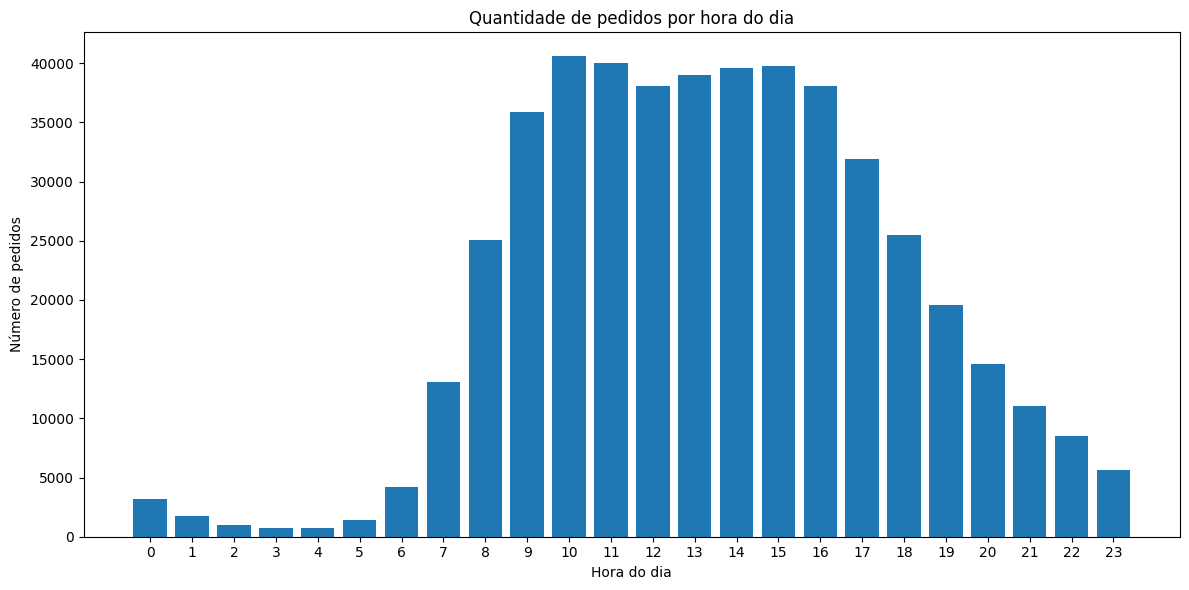

In [15]:
orders_by_hour = (
    orders['order_hour_of_day']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
plt.bar(orders_by_hour.index, orders_by_hour.values)
plt.title('Quantidade de pedidos por hora do dia')
plt.xlabel('Hora do dia')
plt.ylabel('Número de pedidos')
plt.xticks(range(24))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'orders_by_hour.png', dpi=150)
plt.show()

O volume de pedidos é baixo durante a madrugada, cresce rapidamente pela manhã e atinge o maior nível por volta das 10 horas. A maior parte das compras ocorre entre o fim da manhã e o início da noite.

### A3. Quantidade de pedidos por dia da semana

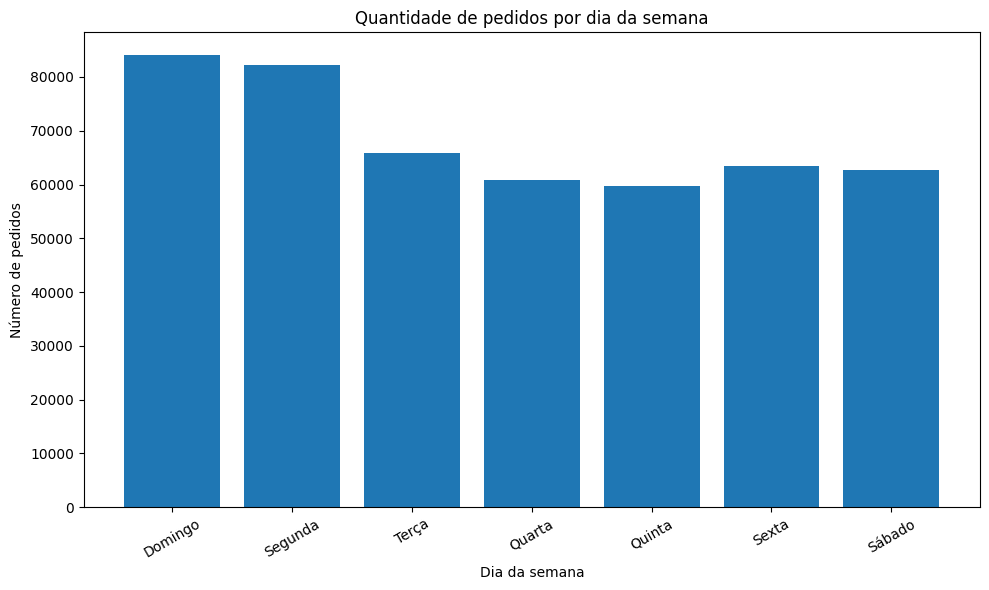

In [16]:
day_names = {
    0: 'Domingo',
    1: 'Segunda',
    2: 'Terça',
    3: 'Quarta',
    4: 'Quinta',
    5: 'Sexta',
    6: 'Sábado'
}

orders_by_day = (
    orders['order_dow']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))
plt.bar(
    [day_names[index] for index in orders_by_day.index],
    orders_by_day.values
)
plt.title('Quantidade de pedidos por dia da semana')
plt.xlabel('Dia da semana')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'orders_by_day.png', dpi=150)
plt.show()

Domingo apresenta o maior número de pedidos, seguido por segunda-feira. Quarta e quinta-feira possuem volumes menores, indicando maior concentração das compras no início da semana e no fim de semana.

### A4. Intervalo até o próximo pedido

Mínimo: 0 dias
Mediana: 7 dias
Média: 11.10 dias
Máximo: 30 dias


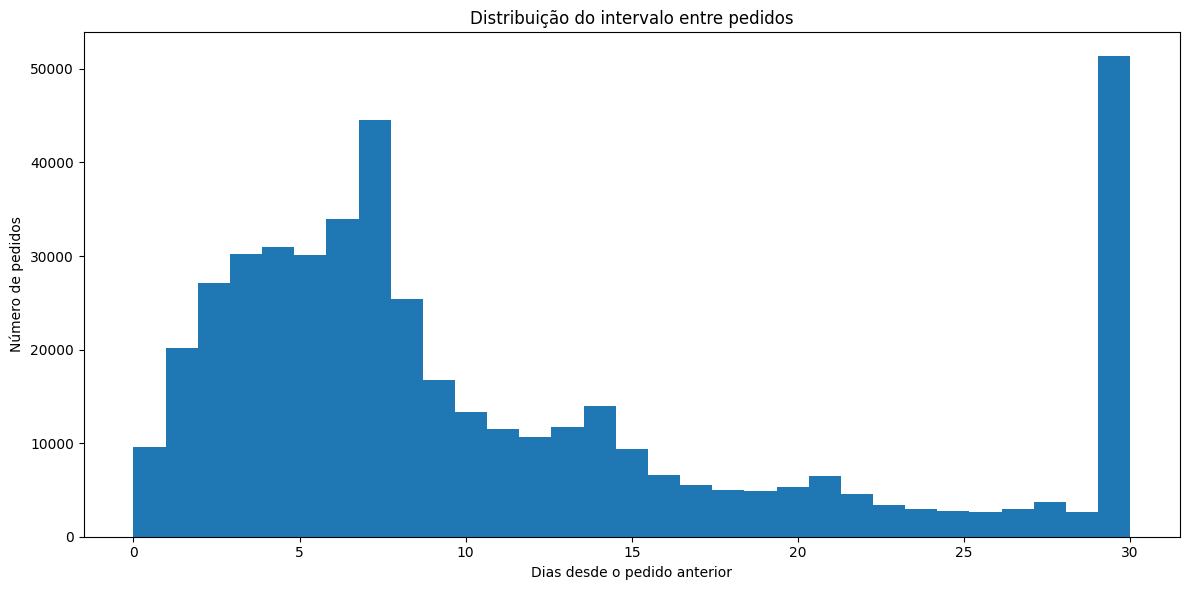

In [17]:
prior_order_days = orders['days_since_prior_order'].dropna()

print(f'Mínimo: {prior_order_days.min():.0f} dias')
print(f'Mediana: {prior_order_days.median():.0f} dias')
print(f'Média: {prior_order_days.mean():.2f} dias')
print(f'Máximo: {prior_order_days.max():.0f} dias')

plt.figure(figsize=(12, 6))
plt.hist(prior_order_days, bins=31)
plt.title('Distribuição do intervalo entre pedidos')
plt.xlabel('Dias desde o pedido anterior')
plt.ylabel('Número de pedidos')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'days_since_prior_order.png', dpi=150)
plt.show()

O intervalo observado varia de 0 a 30 dias, com mediana de 7 dias. Há uma concentração em ciclos semanais e um pico expressivo em 30 dias. Esse limite superior provavelmente reúne clientes que esperaram 30 dias ou mais até a compra seguinte.

## B. Análises obrigatórias

### B1. Horários de pedidos na quarta-feira e no sábado

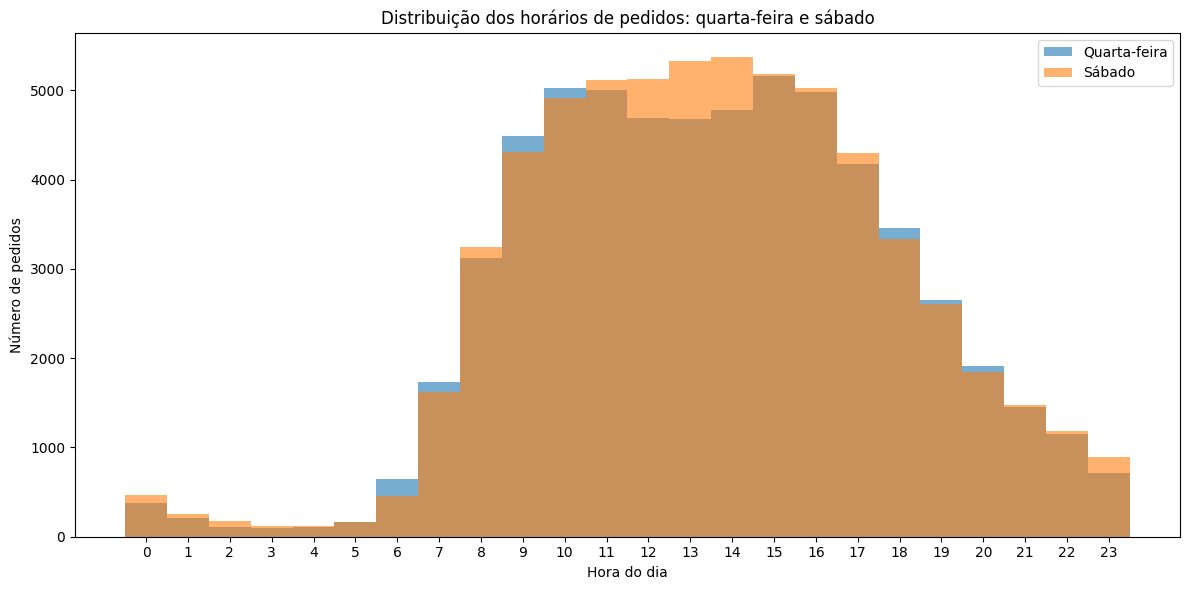

In [18]:
wednesday_hours = orders.loc[
    orders['order_dow'] == 3,
    'order_hour_of_day'
]

saturday_hours = orders.loc[
    orders['order_dow'] == 6,
    'order_hour_of_day'
]

bins = np.arange(-0.5, 24.5, 1)

plt.figure(figsize=(12, 6))
plt.hist(
    wednesday_hours,
    bins=bins,
    alpha=0.6,
    label='Quarta-feira'
)
plt.hist(
    saturday_hours,
    bins=bins,
    alpha=0.6,
    label='Sábado'
)
plt.title('Distribuição dos horários de pedidos: quarta-feira e sábado')
plt.xlabel('Hora do dia')
plt.ylabel('Número de pedidos')
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'wednesday_vs_saturday.png', dpi=150)
plt.show()

As duas distribuições possuem formato semelhante: poucos pedidos durante a madrugada e maior movimento entre o fim da manhã e a tarde. No sábado, o pico ocorre um pouco mais cedo, por volta das 14 horas, enquanto na quarta-feira o maior volume aparece por volta das 15 horas.

### B2. Distribuição do número de pedidos por cliente

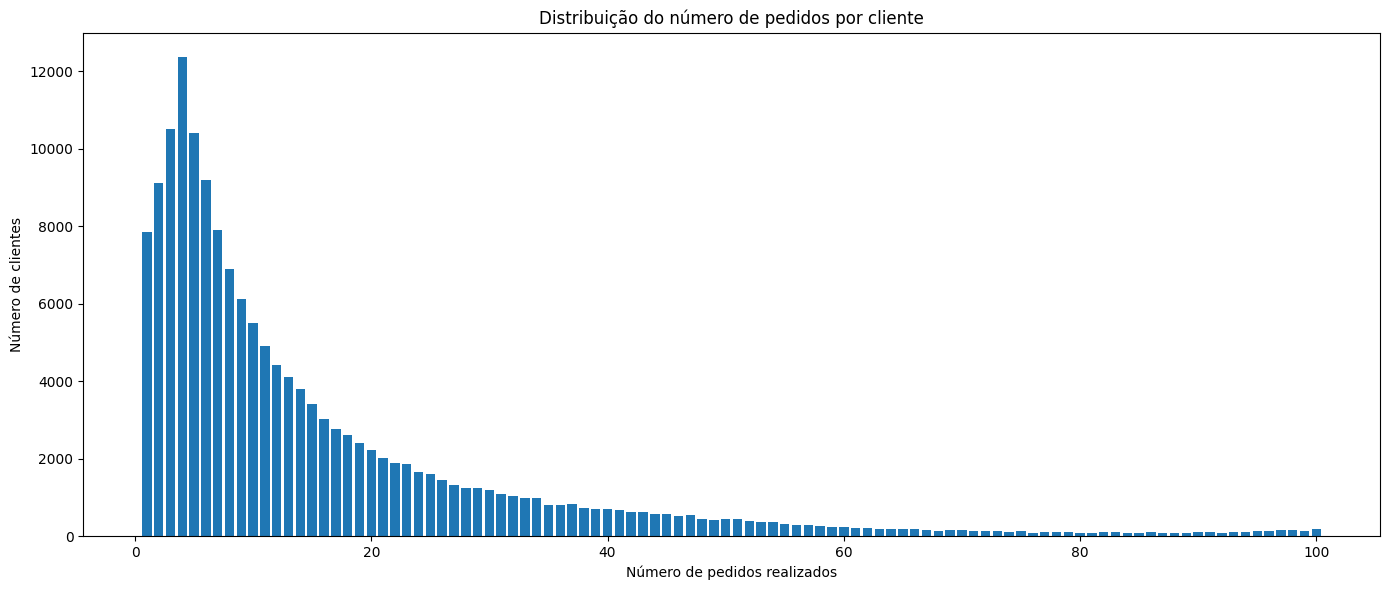

,order_count
count,157437.000
mean,15.578
std,17.216
min,1.000
25%,4.000
50%,9.000
75%,20.000
max,100.000


In [19]:
orders_per_user = (
    orders.groupby('user_id')['order_number']
    .max()
)

customers_by_order_count = (
    orders_per_user
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14, 6))
plt.bar(
    customers_by_order_count.index,
    customers_by_order_count.values
)
plt.title('Distribuição do número de pedidos por cliente')
plt.xlabel('Número de pedidos realizados')
plt.ylabel('Número de clientes')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'orders_per_customer.png', dpi=150)
plt.show()

display(orders_per_user.describe().to_frame('order_count'))

A distribuição é assimétrica à direita. A maior parte dos clientes realizou poucos pedidos, enquanto uma parcela menor possui frequência muito alta. A mediana é de 9 pedidos e o máximo observado é de 100 pedidos.

### B3. Os 20 produtos comprados com maior frequência

,product_id,purchase_count,product_name
22808,24852,66050,Banana
12025,13176,53297,Bag of Organic Bananas
19370,21137,37039,Organic Strawberries
20077,21903,33971,Organic Baby Spinach
43271,47209,29773,Organic Hass Avocado
43788,47766,24689,Organic Avocado
43663,47626,21495,Large Lemon
15364,16797,20018,Strawberries
24047,26209,19690,Limes
25556,27845,19600,Organic Whole Milk


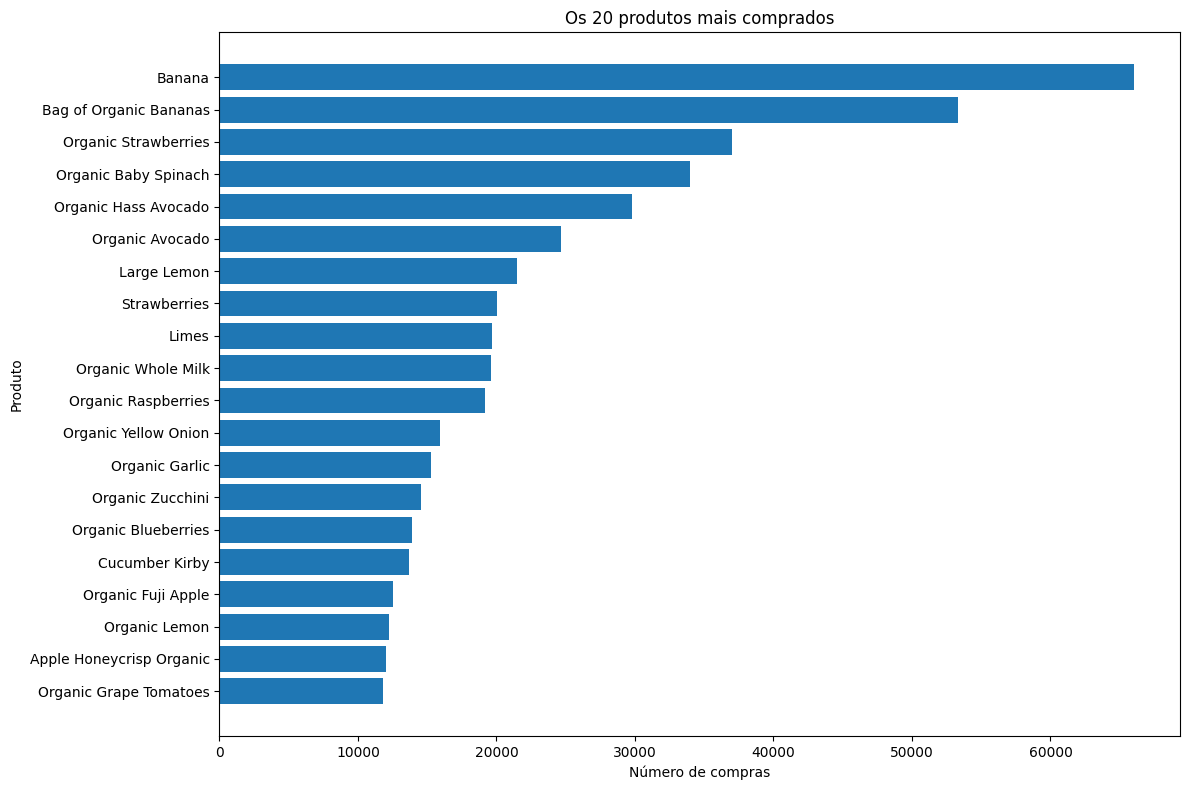

In [20]:
top_20_products = (
    order_products.groupby('product_id')
    .size()
    .reset_index(name='purchase_count')
    .merge(
        products[['product_id', 'product_name']],
        on='product_id',
        how='left'
    )
    .sort_values('purchase_count', ascending=False)
    .head(20)
)

display(top_20_products)

top_20_products.to_csv(
    TABLES_DIR / 'top_20_products.csv',
    index=False
)

plot_data = top_20_products.sort_values('purchase_count')

plt.figure(figsize=(12, 8))
plt.barh(plot_data['product_name'], plot_data['purchase_count'])
plt.title('Os 20 produtos mais comprados')
plt.xlabel('Número de compras')
plt.ylabel('Produto')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_20_products.png', dpi=150)
plt.show()

Banana é o produto mais comprado, seguida por Bag of Organic Bananas. Frutas, verduras, leite e outros itens frescos dominam a lista, indicando forte recorrência de compras de consumo cotidiano.

## C. Análises complementares

### C1. Quantidade de itens por pedido

,item_count
count,450046.000
mean,10.099
std,7.540
min,1.000
25%,5.000
50%,8.000
75%,14.000
max,127.000


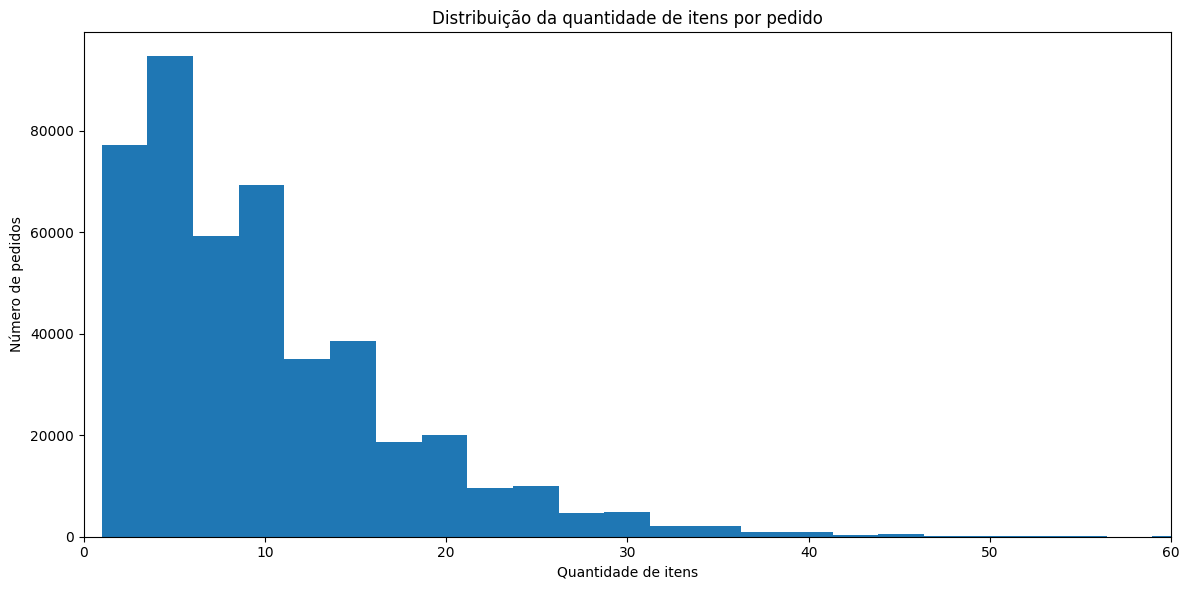

In [21]:
items_per_order = (
    order_products.groupby('order_id')
    .size()
)

display(items_per_order.describe().to_frame('item_count'))

plt.figure(figsize=(12, 6))
plt.hist(items_per_order, bins=50)
plt.title('Distribuição da quantidade de itens por pedido')
plt.xlabel('Quantidade de itens')
plt.ylabel('Número de pedidos')
plt.xlim(0, 60)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'items_per_order.png', dpi=150)
plt.show()

Um pedido típico possui 8 itens pela mediana, enquanto a média é de aproximadamente 10 itens. A distribuição é assimétrica à direita: pedidos pequenos são mais comuns, mas existem carrinhos muito grandes, chegando a 127 itens.

### C2. Os 20 produtos mais presentes em recompras

,product_id,reorder_count,product_name
18104,24852,55763,Banana
9528,13176,44450,Bag of Organic Bananas
15368,21137,28639,Organic Strawberries
15936,21903,26233,Organic Baby Spinach
34407,47209,23629,Organic Hass Avocado
34828,47766,18743,Organic Avocado
20285,27845,16251,Organic Whole Milk
34725,47626,15044,Large Lemon
20375,27966,14748,Organic Raspberries
12193,16797,13945,Strawberries


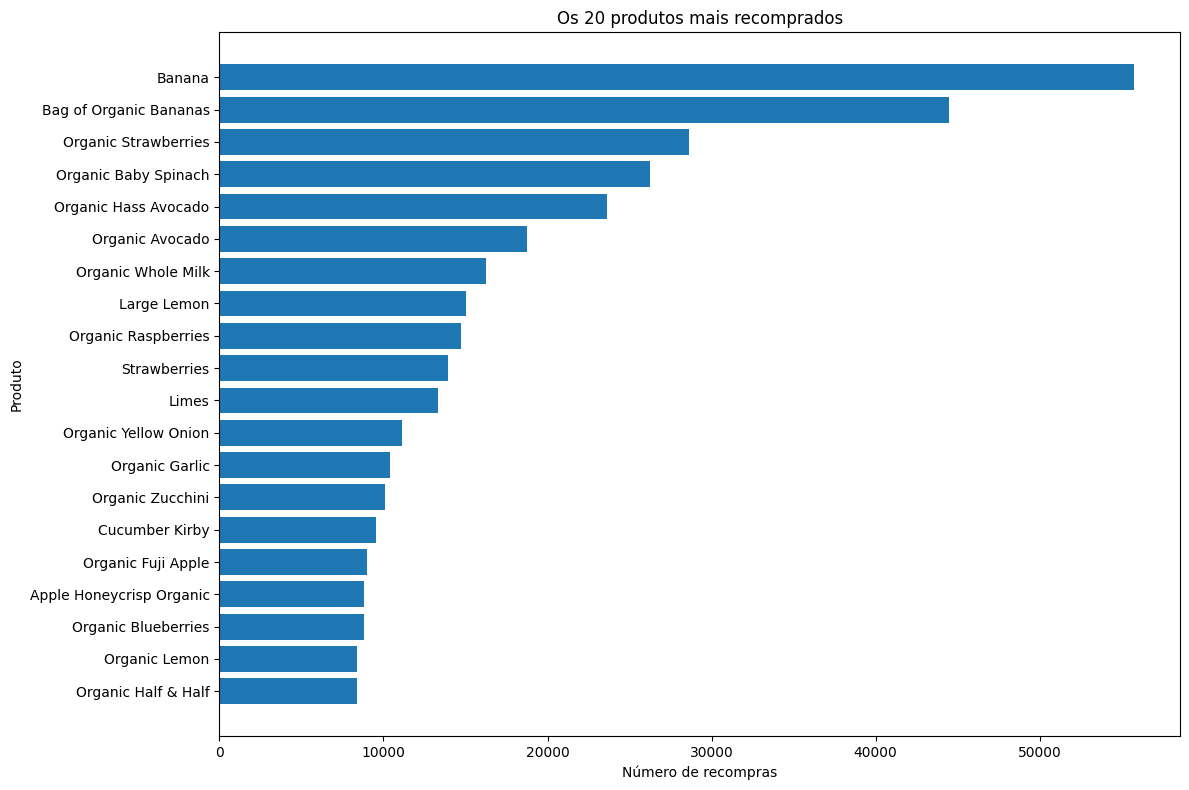

In [22]:
top_20_reordered_products = (
    order_products[order_products['reordered'] == 1]
    .groupby('product_id')
    .size()
    .reset_index(name='reorder_count')
    .merge(
        products[['product_id', 'product_name']],
        on='product_id',
        how='left'
    )
    .sort_values('reorder_count', ascending=False)
    .head(20)
)

display(top_20_reordered_products)

top_20_reordered_products.to_csv(
    TABLES_DIR / 'top_20_reordered_products.csv',
    index=False
)

plot_data = top_20_reordered_products.sort_values('reorder_count')

plt.figure(figsize=(12, 8))
plt.barh(plot_data['product_name'], plot_data['reorder_count'])
plt.title('Os 20 produtos mais recomprados')
plt.xlabel('Número de recompras')
plt.ylabel('Produto')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_20_reordered_products.png', dpi=150)
plt.show()

A lista de produtos mais recomprados é muito semelhante à lista dos mais comprados. Banana, frutas orgânicas, leite e vegetais aparecem nas primeiras posições, reforçando o caráter recorrente desses itens.

### C3. Proporção de recompras por produto

In [23]:
reorder_proportion_by_product = (
    order_products.groupby('product_id')['reordered']
    .mean()
    .reset_index(name='reorder_proportion')
    .merge(
        products[['product_id', 'product_name']],
        on='product_id',
        how='left'
    )
    [['product_id', 'product_name', 'reorder_proportion']]
)

display(
    reorder_proportion_by_product
    .sort_values('reorder_proportion', ascending=False)
    .head(20)
)

reorder_proportion_by_product.to_csv(
    TABLES_DIR / 'reorder_proportion_by_product.csv',
    index=False
)

,product_id,product_name,reorder_proportion
26746,29146,Pomegranate Sangria Seltzer,1.000
45503,49619,Opo Squash,1.000
45508,49625,Golden Wheat Deep Cleanse Shampoo,1.000
22845,24896,Snack- Sweet Chili- Original,1.000
22850,24901,Clear Ammonia,1.000
22795,24839,Dark Chocolate Coconut Bars,1.000
21375,23309,Fruit Spread- Chia- Strawberry- with Agave Syrup,1.000
4363,4784,Instant Sea Vegetable Wakame,1.000
37534,40959,Quart Freezer Slider Bags,1.000
23421,25526,Bread & Butter Chips Pickles,1.000


A proporção foi calculada pela média da coluna binária `reordered`. Valores próximos de 1 indicam que quase todas as aparições do produto correspondem a recompras. Produtos com poucas ocorrências podem atingir proporções extremas, por isso a frequência absoluta também deve ser considerada em análises de negócio.

### C4. Proporção de produtos recomprados por cliente

,user_id,reorder_proportion
0,2,0.038
1,4,0.000
2,5,0.667
3,6,0.000
4,7,0.929


count   149626.000
mean         0.495
std          0.293
min          0.000
25%          0.273
50%          0.500
75%          0.724
max          1.000
Name: reorder_proportion, dtype: float64

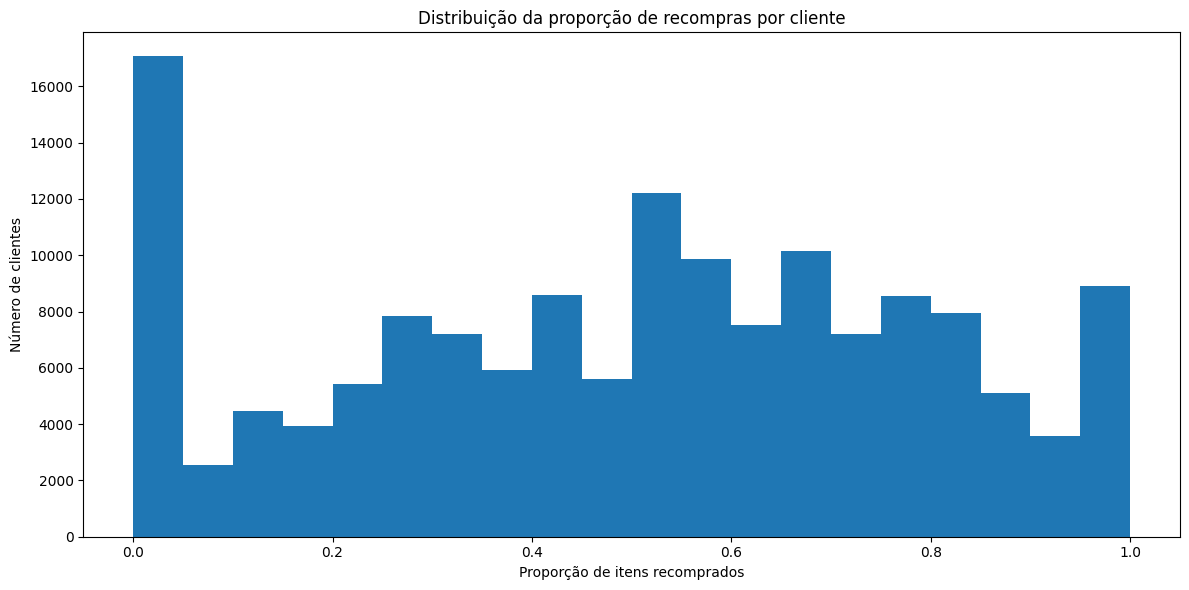

In [24]:
order_products_with_users = order_products.merge(
    orders[['order_id', 'user_id']],
    on='order_id',
    how='left'
)

reorder_proportion_by_user = (
    order_products_with_users
    .groupby('user_id')['reordered']
    .mean()
    .reset_index(name='reorder_proportion')
)

display(reorder_proportion_by_user.head())
display(reorder_proportion_by_user['reorder_proportion'].describe())

reorder_proportion_by_user.to_csv(
    TABLES_DIR / 'reorder_proportion_by_user.csv',
    index=False
)

plt.figure(figsize=(12, 6))
plt.hist(reorder_proportion_by_user['reorder_proportion'], bins=20)
plt.title('Distribuição da proporção de recompras por cliente')
plt.xlabel('Proporção de itens recomprados')
plt.ylabel('Número de clientes')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'reorder_proportion_by_user.png', dpi=150)
plt.show()

A mediana da proporção de recompras por cliente é aproximadamente 0,50. Isso significa que, para um cliente típico, cerca de metade dos itens comprados já havia sido adquirida anteriormente.

### C5. Produtos adicionados primeiro ao carrinho

,product_id,first_added_count,product_name
13414,24852,15562,Banana
7127,13176,11026,Bag of Organic Bananas
15028,27845,4363,Organic Whole Milk
11384,21137,3946,Organic Strawberries
25439,47209,3390,Organic Hass Avocado
11786,21903,3336,Organic Baby Spinach
25732,47766,3044,Organic Avocado
10622,19660,2336,Spring Water
9050,16797,2308,Strawberries
15102,27966,2024,Organic Raspberries


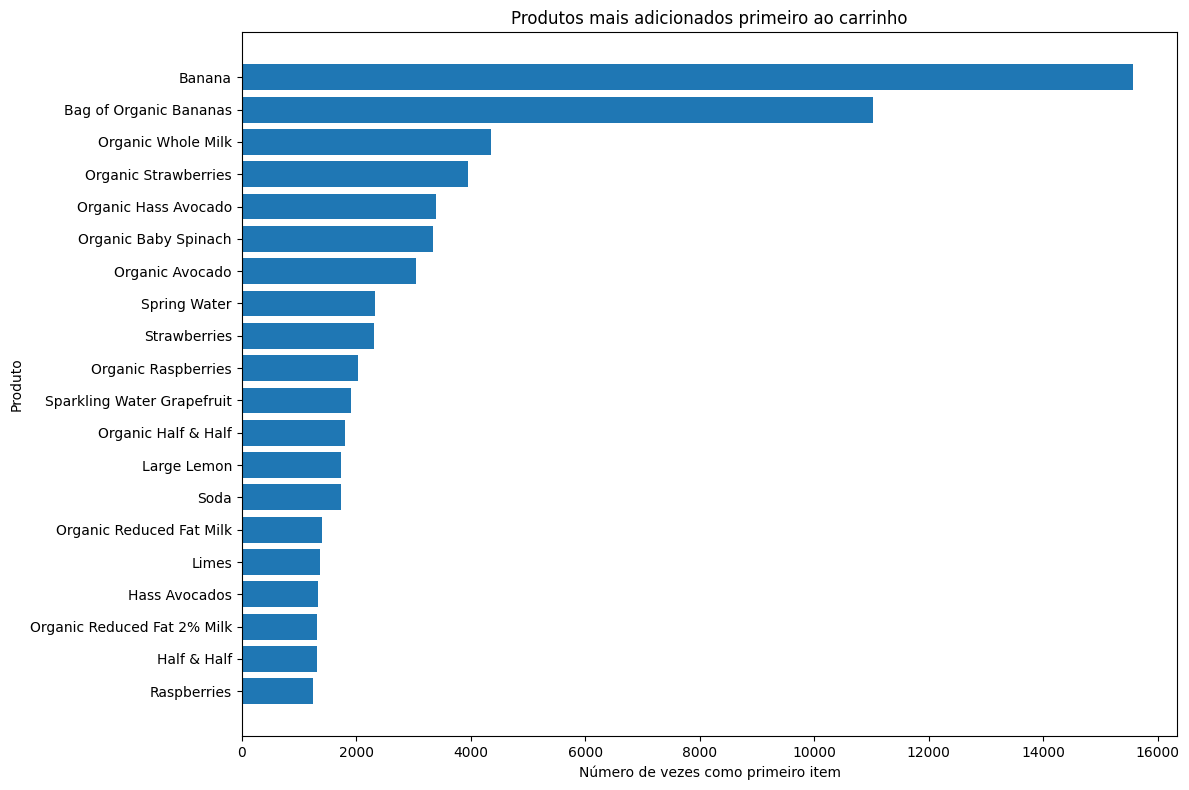

In [25]:
top_20_first_added = (
    order_products[order_products['add_to_cart_order'] == 1]
    .groupby('product_id')
    .size()
    .reset_index(name='first_added_count')
    .merge(
        products[['product_id', 'product_name']],
        on='product_id',
        how='left'
    )
    .sort_values('first_added_count', ascending=False)
    .head(20)
)

display(top_20_first_added)

top_20_first_added.to_csv(
    TABLES_DIR / 'top_20_first_added.csv',
    index=False
)

plot_data = top_20_first_added.sort_values('first_added_count')

plt.figure(figsize=(12, 8))
plt.barh(plot_data['product_name'], plot_data['first_added_count'])
plt.title('Produtos mais adicionados primeiro ao carrinho')
plt.xlabel('Número de vezes como primeiro item')
plt.ylabel('Produto')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_20_first_added.png', dpi=150)
plt.show()

Banana e Bag of Organic Bananas também lideram entre os produtos adicionados primeiro ao carrinho. Isso sugere que são itens planejados e lembrados logo no início da montagem do pedido.

## 4. Conclusões

A análise identificou padrões claros no comportamento dos clientes:

1. Os pedidos se concentram entre a manhã e o início da noite, com pico por volta das 10 horas.
2. Domingo é o dia com maior volume de pedidos.
3. O intervalo típico entre compras é de 7 dias, indicando forte comportamento semanal.
4. A maior parte dos clientes possui frequência moderada, mas existe uma cauda de consumidores muito recorrentes.
5. Frutas, verduras e laticínios aparecem entre os itens mais comprados, recomprados e adicionados primeiro ao carrinho.
6. Um pedido típico contém aproximadamente 8 itens.
7. Para o cliente mediano, cerca de metade dos itens comprados corresponde a recompras.

Esses resultados podem ajudar em decisões de estoque, campanhas de recompra, recomendações personalizadas e planejamento operacional por horário e dia da semana.